In [ ]:
# 訓練データとテストデータの画像を読み込む
# （サイズは縦横224pxにリサイズする）
import tensorflow as tf

train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "dog_cat_photos/train",
    image_size=(224, 224),
    label_mode="binary",
    batch_size=32,
    shuffle=True
)

test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "dog_cat_photos/test",
    image_size=(224, 224),
    label_mode="binary",
    batch_size=32,
    shuffle=False
)

Found 300 files belonging to 2 classes.
Found 100 files belonging to 2 classes.


In [ ]:
## データの詳細を表示する
list(train_dataset.as_numpy_iterator())[0]

(array([[[[126.       , 124.       ,  85.       ],
          [126.04911  , 124.02679  ,  85.0067   ],
          [133.41518  , 128.04465  ,  86.01116  ],
          ...,
          [ 25.292435 ,  22.292435 ,   7.2924347],
          [ 28.975494 ,  25.975494 ,  10.975494 ],
          [ 29.       ,  26.       ,  11.       ]],
 
         [[125.83929  , 123.8817   ,  84.8683   ],
          [125.88831  , 123.90845  ,  84.87496  ],
          [133.24167  , 127.921074 ,  85.87344  ],
          ...,
          [ 25.294064 ,  22.298529 ,   7.290327 ],
          [ 28.964418 ,  25.968882 ,  10.962176 ],
          [ 28.98884  ,  25.993303 ,  10.986608 ]],
 
         [[101.73214  , 106.13616  ,  65.11384  ],
          [101.76846  , 106.157684 ,  65.11452  ],
          [107.216034 , 109.38557  ,  65.216156 ],
          ...,
          [ 25.53844  ,  23.21255  ,   6.974179 ],
          [ 27.302992 ,  24.977098 ,   8.964436 ],
          [ 27.314732 ,  24.988838 ,   8.977678 ]],
 
         ...,
 
         [[ 

In [3]:
class_names = train_dataset.class_names
class_names

['cat', 'dog']

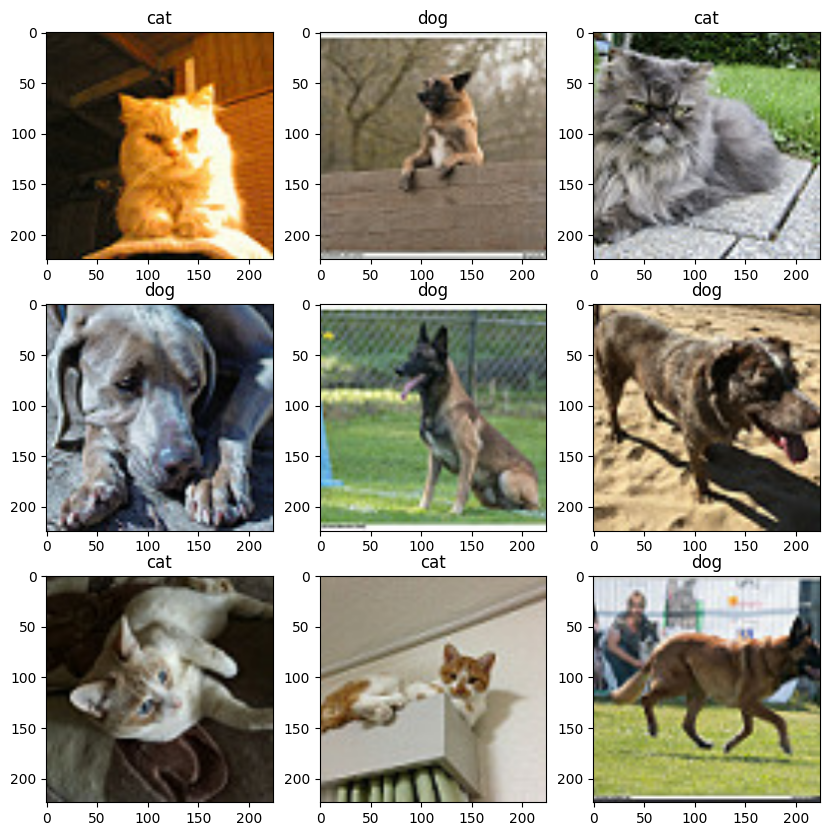

In [ ]:
## 訓練データの一部を表示
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy().astype("uint8")[0]])

In [5]:
# 画像の水増しをする関数の定義
def flip_left_right(image, label):   # 左右反転
    image = tf.image.flip_left_right(image)
    return image, label

def flip_up_down(image, label):      # 上下反転
    image = tf.image.flip_up_down(image)
    return image, label

def rot90(image, label):             # 反時計回りに90度回転
    image = tf.image.rot90(image)
    return image, label

def rot180(image, label):            # 反時計回りに180度回転
    image = tf.image.rot90(image, k=2)
    return image, label

def rot270(image, label):            # 反時計回りに270度回転
    image = tf.image.rot90(image, k=3)
    return image, label


In [6]:
# 画像の水増し処理の実行
train_dataset_lr     = train_dataset.map(flip_left_right)
train_dataset_ud     = train_dataset.map(flip_up_down)
train_dataset_rot90  = train_dataset.map(rot90)
train_dataset_rot180 = train_dataset.map(rot180)
train_dataset_rot270 = train_dataset.map(rot270)

In [7]:
# 水増ししたデータを訓練データに追加する
train_dataset = train_dataset.concatenate(train_dataset_lr)
train_dataset = train_dataset.concatenate(train_dataset_ud)
train_dataset = train_dataset.concatenate(train_dataset_rot90)
train_dataset = train_dataset.concatenate(train_dataset_rot180)
train_dataset = train_dataset.concatenate(train_dataset_rot270)

In [8]:
# データをシャッフルする
train_dataset = train_dataset.shuffle(32)

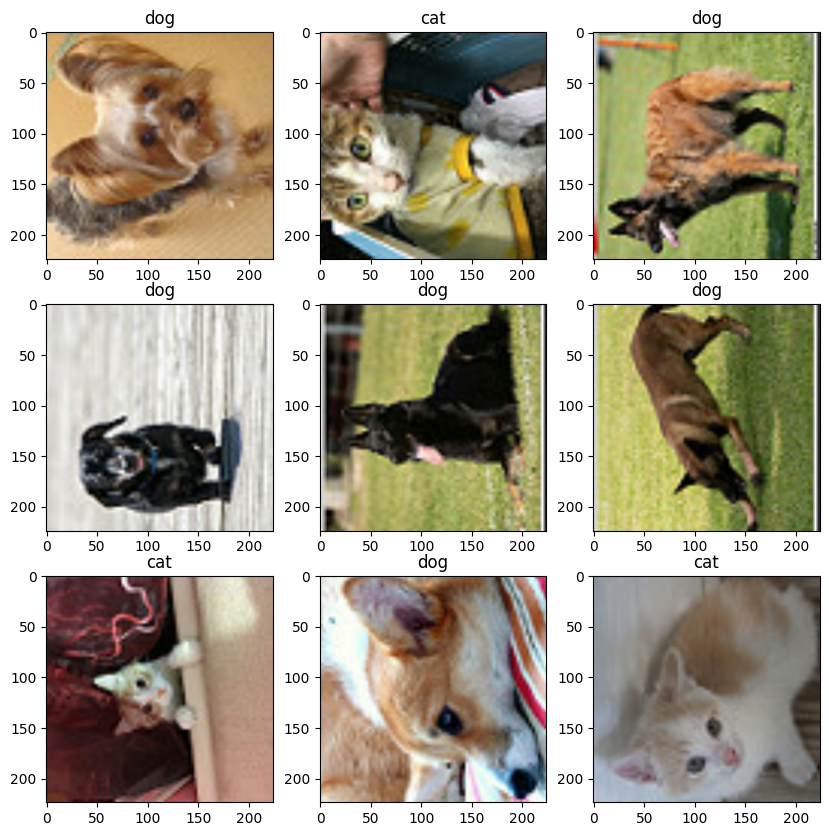

In [11]:
# 訓練データの一部を表示して確認
plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy().astype("uint8")[0]])

In [ ]:
# MobileNetV2モデルを作成する
input_layer = tf.keras.Input(shape=(224, 224, 3))   # 入力層の作成
l_layer = tf.keras.applications.mobilenet_v2.preprocess_input(input_layer)   # 前処理（正規化）をする層

base_model = tf.keras.applications.mobilenet_v2.MobileNetV2(
    input_shape=(224, 224, 3),
    input_tensor=l_layer,
    include_top=False,
    weights="imagenet",
    pooling='avg'
)
base_model.trainable = False

In [13]:
#出力層の作成
# Dense層を追加する
output_layer = tf.keras.layers.Dense(1, activation='sigmoid')

In [14]:
# base_modelに先ほどのDense層を追加したモデルを作成する
model = tf.keras.Sequential([
    base_model,
    output_layer
])

In [15]:
# modelをcompileする
model.compile(optimizer="adam",
              loss='binary_crossentropy',
              metrics=["accuracy"])

In [16]:
# modelに学習させる
model.fit(train_dataset, epochs=20)

Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 39s 516ms/step - accuracy: 0.8228 - loss: 0.3964
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 31s 501ms/step - accuracy: 0.9311 - loss: 0.2070
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 31s 508ms/step - accuracy: 0.9506 - loss: 0.1604
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 31s 505ms/step - accuracy: 0.9622 - loss: 0.1299
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 32s 515ms/step - accuracy: 0.9689 - loss: 0.1129
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 31s 511ms/step - accuracy: 0.9733 - loss: 0.0971
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 31s 507ms/step - accuracy: 0.9794 - loss: 0.0868
Epoch 8/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 31s 506ms/step - accuracy: 0.9839 - loss: 0.0783
Epoch 9/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 31s 506ms/step - accuracy: 0.9861 - loss: 0.0670
Epoch 10/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 31s 508ms/step - accuracy: 0.9900 - loss: 0.0609
Epoch 11/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 31s 511ms/step - accuracy: 0.9906 - loss: 0.0580
Epoch 12/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 32

In [17]:
# テストデータで分類を実行する
pred_data = model.predict(test_dataset)

4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 909ms/step


In [18]:
# 分類した結果を確認する
pred_data

array([[3.12631237e-05],
       [4.33645328e-04],
       [9.57104421e-05],
       [3.66322137e-03],
       [3.86245316e-04],
       [1.49538799e-04],
       [6.94051792e-04],
       [6.18946156e-04],
       [9.66000880e-06],
       [2.89822987e-04],
       [4.29800966e-05],
       [6.51793368e-03],
       [4.68840450e-03],
       [7.35841459e-04],
       [1.33481837e-04],
       [5.34083938e-06],
       [9.68842505e-05],
       [6.70168141e-04],
       [5.92964469e-03],
       [3.34553514e-03],
       [6.23325864e-03],
       [1.00392215e-01],
       [4.87043476e-03],
       [1.15757994e-03],
       [3.10207307e-01],
       [1.78756134e-03],
       [7.94885680e-04],
       [5.55201957e-04],
       [6.39543124e-03],
       [2.70537712e-04],
       [1.53436640e-03],
       [7.24094808e-01],
       [2.89925229e-04],
       [1.18439447e-03],
       [4.68215765e-03],
       [9.49031830e-01],
       [3.89236654e-03],
       [1.38759403e-03],
       [5.34964986e-02],
       [8.06935073e-04],


In [ ]:
# evaluate()でモデルの性能を評価する
model.evaluate(test_dataset)